In [2]:
import pandas as pd
df = pd.read_excel("student_data.xlsx")
display(df)

,Student_ID,Attendance,Study_Hours,Internal_Marks,Assignment_Marks,Previous_Marks,Result
0,S001,85,4.5,78,82,75,1
1,S002,62,1.5,42,48,40,0
2,S003,91,5.5,88,92,86,1
3,S004,70,2.0,55,60,52,0
4,S005,78,3.5,68,74,65,1
...,...,...,...,...,...,...,...
145,S146,63,1.5,42,47,39,0
146,S147,91,5.5,88,93,86,1
147,S148,78,3.0,66,72,63,1
148,S149,58,1.0,35,40,32,0


In [3]:
df.head()

,Student_ID,Attendance,Study_Hours,Internal_Marks,Assignment_Marks,Previous_Marks,Result
0,S001,85,4.5,78,82,75,1
1,S002,62,1.5,42,48,40,0
2,S003,91,5.5,88,92,86,1
3,S004,70,2.0,55,60,52,0
4,S005,78,3.5,68,74,65,1


In [4]:
print(df.shape)

(150, 7)


In [5]:
print(df.columns)

Index(['Student_ID', 'Attendance', 'Study_Hours', 'Internal_Marks',
       'Assignment_Marks', 'Previous_Marks', 'Result'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        150 non-null    object 
 1   Attendance        150 non-null    int64  
 2   Study_Hours       150 non-null    float64
 3   Internal_Marks    150 non-null    int64  
 4   Assignment_Marks  150 non-null    int64  
 5   Previous_Marks    150 non-null    int64  
 6   Result            150 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 8.3+ KB
None


In [7]:
print(df.isnull().sum())

Student_ID          0
Attendance          0
Study_Hours         0
Internal_Marks      0
Assignment_Marks    0
Previous_Marks      0
Result              0
dtype: int64


In [8]:
print(df["Result"].value_counts())

Result
1    88
0    62
Name: count, dtype: int64


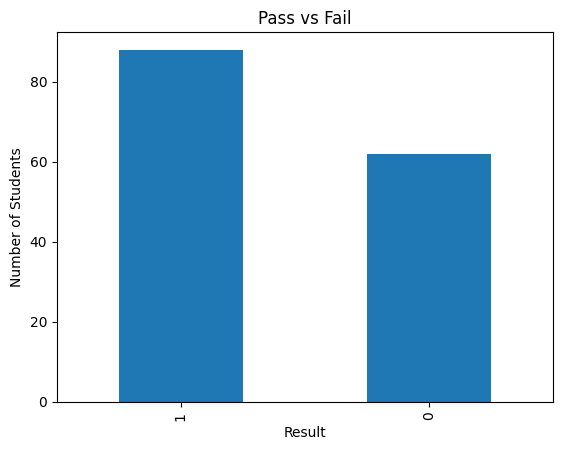

In [9]:
import matplotlib.pyplot as plt

df["Result"].value_counts().plot(kind="bar")

plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.title("Pass vs Fail")
plt.show()

In [10]:
X = df[
    [
        "Attendance",
        "Study_Hours",
        "Internal_Marks",
        "Assignment_Marks",
        "Previous_Marks"
    ]
]

In [11]:
y = df["Result"]

In [ ]:
print(X.head())

   Attendance  Study_Hours  Internal_Marks  Assignment_Marks  Previous_Marks
0          85          4.5              78                82              75
1          62          1.5              42                48              40
2          91          5.5              88                92              86
3          70          2.0              55                60              52
4          78          3.5              68                74              65


In [12]:
print(y.head())

0    1
1    0
2    1
3    0
4    1
Name: Result, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 5)
Testing data: (30, 5)


In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
model = LogisticRegression()

In [17]:
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
print(y_pred)

[1 0 1 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1]


In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        0          0
4        1          1
5        1          1
6        1          1
7        0          0
8        1          1
9        1          1
10       0          0
11       0          0
12       0          0
13       1          1
14       1          1
15       0          0
16       1          1
17       0          0
18       1          1
19       0          0
20       0          0
21       1          1
22       0          0
23       0          0
24       1          1
25       1          1
26       1          1
27       1          1
28       1          1
29       1          1


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy percentage: 100.0 %


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        18

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12  0]
 [ 0 18]]


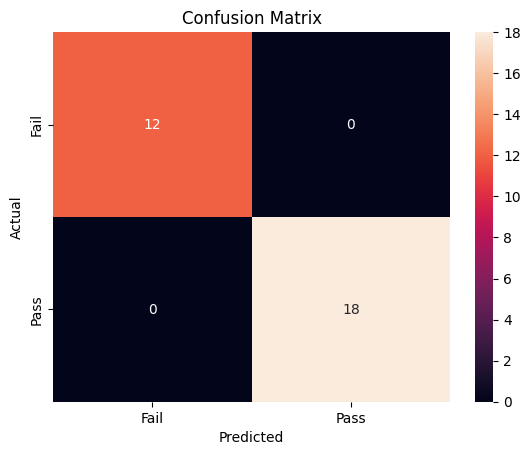

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
new_student = [[85, 4, 75, 80, 70]]

In [27]:
new_student = pd.DataFrame(
    [[85, 4, 75, 80, 70]],
    columns=[
        "Attendance",
        "Study_Hours",
        "Internal_Marks",
        "Assignment_Marks",
        "Previous_Marks"
    ]
)

prediction = model.predict(new_student)

print(prediction)

[1]


In [28]:
if prediction[0] == 1:
    print("Predicted Result: PASS")
else:
    print("Predicted Result: FAIL")

Predicted Result: PASS


In [29]:
probability = model.predict_proba(new_student)

print("Fail probability:", f"{probability[0][0]:.2f}")
print("Pass probability:", f"{probability[0][1]:.2f}")

Fail probability: 0.00
Pass probability: 1.00


  Student_ID  Attendance  Study_Hours  Internal_Marks  Assignment_Marks  \
0       S001          85          4.5              78                82   
1       S002          62          1.5              42                48   
2       S003          91          5.5              88                92   
3       S004          70          2.0              55                60   
4       S005          78          3.5              68                74   

   Previous_Marks  Result  
0              75       1  
1              40       0  
2              86       1  
3              52       0  
4              65       1  
Dataset size: (150, 7)

Missing values:
Student_ID          0
Attendance          0
Study_Hours         0
Internal_Marks      0
Assignment_Marks    0
Previous_Marks      0
Result              0
dtype: int64

Result distribution:
Result
1    88
0    62
Name: count, dtype: int64

Training data: (120, 5)
Testing data: (30, 5)

Model training completed!

Accuracy: 1.0
Accuracy perce

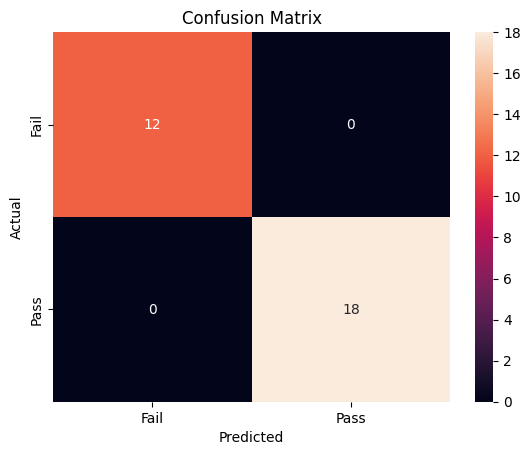


New Student Result: PASS

Fail probability: 0.00
Pass probability: 1.00

Fail probability: 0.00%
Pass probability: 100.00%


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# 1. Load dataset
df = pd.read_excel("student_data.xlsx")


# 2. Display dataset
print(df.head())


# 3. Check dataset size
print("Dataset size:", df.shape)


# 4. Check missing values
print("\nMissing values:")
print(df.isnull().sum())


# 5. Check Result distribution
print("\nResult distribution:")
print(df["Result"].value_counts())


# 6. Select input features
X = df[
    [
        "Attendance",
        "Study_Hours",
        "Internal_Marks",
        "Assignment_Marks",
        "Previous_Marks"
    ]
]


# 7. Select target
y = df["Result"]


# 8. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# 9. Create model
model = LogisticRegression()


# 10. Train model
model.fit(X_train, y_train)

print("\nModel training completed!")


# 11. Predict test data
y_pred = model.predict(X_test)


# 12. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy percentage:", f"{accuracy * 100:.2f}%")


# 13. Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 14. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# 15. Display confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 16. New student prediction

new_student = pd.DataFrame(
    [[85, 4, 75, 80, 70]],
    columns=[
        "Attendance",
        "Study_Hours",
        "Internal_Marks",
        "Assignment_Marks",
        "Previous_Marks"
    ]
)


prediction = model.predict(new_student)


if prediction[0] == 1:
    print("\nNew Student Result: PASS")
else:
    print("\nNew Student Result: FAIL")


# 17. Prediction probability

probability = model.predict_proba(new_student)


print("\nFail probability:", f"{probability[0][0]:.2f}")
print("Pass probability:", f"{probability[0][1]:.2f}")


# 18. Prediction probability in percentage

print("\nFail probability:", f"{probability[0][0] * 100:.2f}%")
print("Pass probability:", f"{probability[0][1] * 100:.2f}%")

In [31]:
X = df[["Attendance", "Study_Hours", "Internal_Marks",
        "Assignment_Marks", "Previous_Marks"]]

y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)